In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
visa_df=pd.read_csv(r"D:\data files\Visadataset.csv")
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [3]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [ ]:
                         # why scaling
- scaling preserve the numerical statbility across the columns

    -ex : age :20   salary:50000 exp:2

    -different columns having the differnet scale(limit)

    -we want to keep all the coloumns under same limit

    -if we dont keep under the same scale some ml algo feels salary is the important column
     because of highest value.

                       # faster training
    
- some of ml algorithms  like knn,kmeans,svm are distance based algorithms

- if we lower the values the calculation are fast

- in every model development will do math calculations

- in order to increse the fastness(optimization) scaling is very helpful
    

#                                         z-score or z scale

<img src="https://toptipbio.com/wp-content/uploads/2018/07/Z-score-formula.jpg" jsaction="" class="sFlh5c FyHeAf iPVvYb" style="max-width: 435px; height: 291px; margin: 0px; width: 357px;" alt="What Is A Z-Score And How To Calculate Them?" jsname="kn3ccd">

In [4]:
visa_df['prevailing_wage']

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [5]:
# step-1 wage_mean=wage_data.mean()
# step-2 wage_sd
# step-3 nr=wage_data-wage_mean
# step-4 nr/wage_sd

In [6]:
wage_data=visa_df['prevailing_wage']
wage_mean=wage_data.mean()
wage_sd=wage_data.std()
nr=wage_data-wage_mean
wage_z=nr/wage_sd

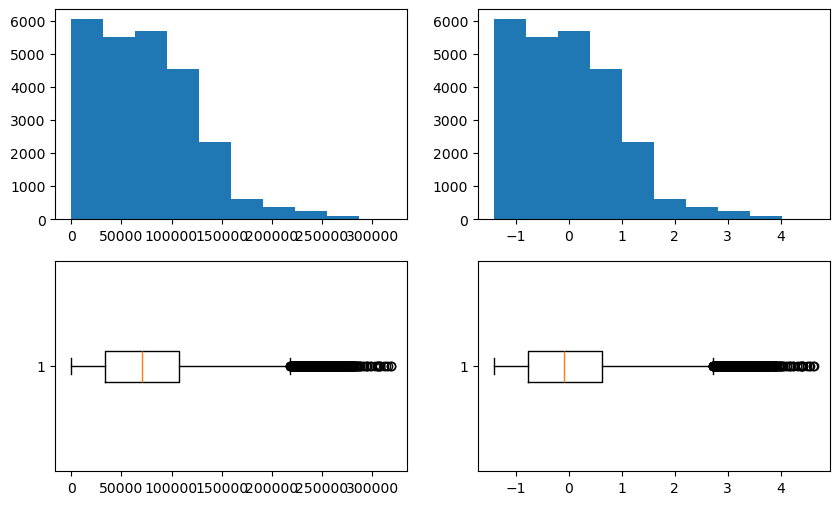

In [7]:
# old_data : wage_data
# z_data  : wage_z

plt.figure(figsize=(10,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_z)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_z,vert=False)
plt.show()

In [ ]:
-sklearn
  -preprocessing
   -statndarscalar
     - fit_transform

In [8]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
wage_data_ss=ss.fit_transform(visa_df[['prevailing_wage']])


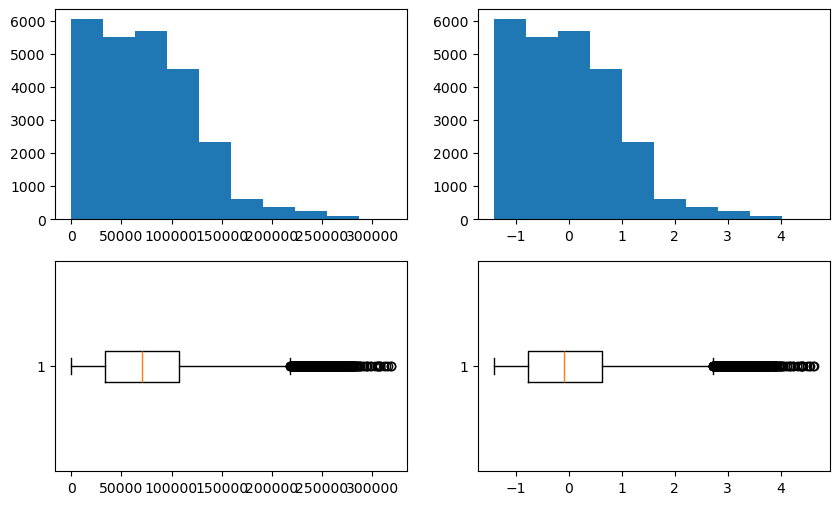

In [9]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_data_ss)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_data_ss,vert=False)
plt.show()

#                     normalization

<img src="https://miro.medium.com/v2/resize:fit:964/1*OnCBKS-Thqa43qNslohDpA.png" jsaction="" class="sFlh5c FyHeAf iPVvYb" style="max-width: 482px; width: 357px; height: 122px; margin: 8.5px 0px;" alt="Min-Max Normalization. Instead of directly jumping into the… | by Abhinav  Bandaru | Medium" jsname="kn3ccd">

In [ ]:
# step-1 : wage_min
# step-2 : wage_max
# step-3 : Nr=wage_data-wage_min
# step-4 : dr=wage_max-wage_min
# step-5 : wage_norm=nr/dr

In [ ]:
# standardscalar is called as a z score
# minmaxscalar is called as norm 0 to 1
-sklearn
  -preprocessing
   -minmaxscalar
     - fit_transform

In [10]:
wage_data=visa_df['prevailing_wage']
wage_mean=wage_data.mean()
wage_max=wage_data.max()
wage_min=wage_data.min()
nr=wage_data-wage_min
dr=wage_min+wage_max
wage_norm=(nr/dr)
wage_norm

0        0.001849
1        0.261342
2        0.385307
3        0.261368
4        0.469610
           ...   
25475    0.241502
25476    0.874567
25477    0.458305
25478    0.269891
25479    0.222030
Name: prevailing_wage, Length: 25480, dtype: float64

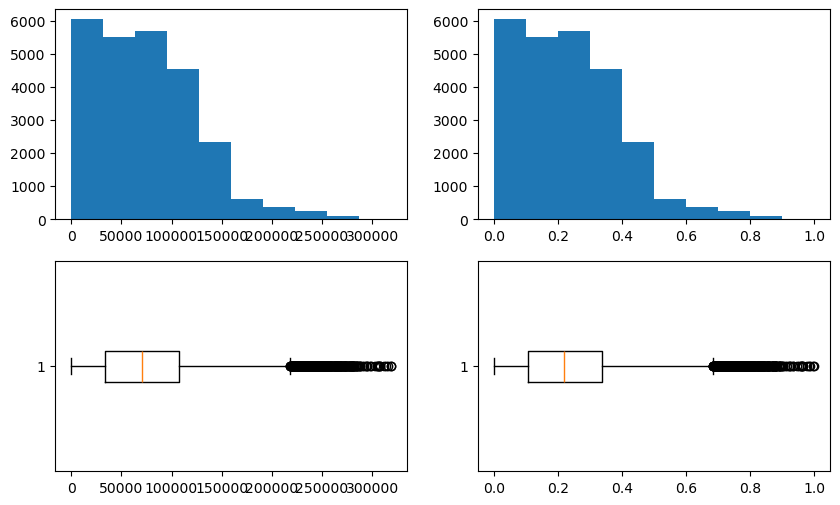

In [11]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_norm)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_norm,vert=False)
plt.show()

In [ ]:
# missing value analysis